In [6]:
import pandas as pd
import os
from tqdm import tqdm


def process_and_save_data(input_csv_path, output_dir):
    print(f"Processing and saving data from {input_csv_path} to {output_dir}")
    df = pd.read_csv(input_csv_path, usecols=['timestamp', 'msinstanceid', 'cpu_utilization'])

    # 提取 msinstanceid 中的第一个数字并转换为整数
    df['ms'] = df['msinstanceid'].apply(lambda x: int(x.split('_')[1]))
    df = df[df['ms'] < 100]

    # 只保留 timestamp 为 300000 整数倍的数据
    df = df[df['timestamp'] % 300000 == 0]
    grouped = df.groupby('msinstanceid')

    # 确保输出目录存在
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for msinstanceid, data in tqdm(grouped):
        data = data[['timestamp', 'cpu_utilization']]
        data = data.sort_values(by=['timestamp'])
        data['cpu_utilization'] = data['cpu_utilization'].apply(lambda x: min(x * 6, 0.99))
        output_file_path = os.path.join(output_dir, f'{msinstanceid}.csv')
        # 如果文件存在，追加到文件后面而不是覆盖
        if os.path.exists(output_file_path):
            data.to_csv(output_file_path, mode='a', header=False, index=False)
        else:
            data.to_csv(output_file_path, index=False)

In [7]:
process_and_save_data('data/MSMetrics/MSMetricsUpdate_0.csv', "data/processed")

Processing and saving data from data/MSMetrics/MSMetricsUpdate_0.csv to data/processed


100%|██████████| 612/612 [00:00<00:00, 1398.14it/s]


In [21]:
# 分别统计目录中各csv文件的 cpu_utilization 与 memory_utilization 的方差，存储到同一个 df 中
def calculate_variance_for_all_files(directory):
    result = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv'):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, usecols=['cpu_utilization'])
            variance_cpu = df['cpu_utilization'].var()
            # 向 result 添加一行
            result.append([filename, variance_cpu])
    # 将result转成DataFrame
    result = pd.DataFrame(result, columns=['filename', 'variance_cpu'])
    # 按照 variance_cpu 与 variance_memory 的和降序
    result = result.sort_values(by=['variance_cpu'], ascending=[False])
    return result

In [22]:
vvv = calculate_variance_for_all_files("data/processed")
vvv.head()

,filename,variance_cpu
37,MS_10000_POD_7.csv,0.009579
28,MS_10000_POD_14.csv,0.009164
0,MS_10000_POD_40.csv,0.007475
16,MS_10000_POD_30.csv,0.006662
29,MS_10000_POD_28.csv,0.006206


In [8]:
import matplotlib.pyplot as plt


def plot_cpu_memory_utilization(input_csv_path):
    # 读取CSV文件
    df = pd.read_csv(input_csv_path, usecols=['timestamp', 'cpu_utilization'])

    df['timestamp'] = df['timestamp'] / 1000

    # 绘制折线图
    plt.figure(figsize=(14, 7))
    plt.plot(df['timestamp'], df['cpu_utilization'], label='CPU Utilization')
    plt.xlabel('Seconds')
    plt.ylabel('Utilization')
    plt.title('CPU Utilization Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()


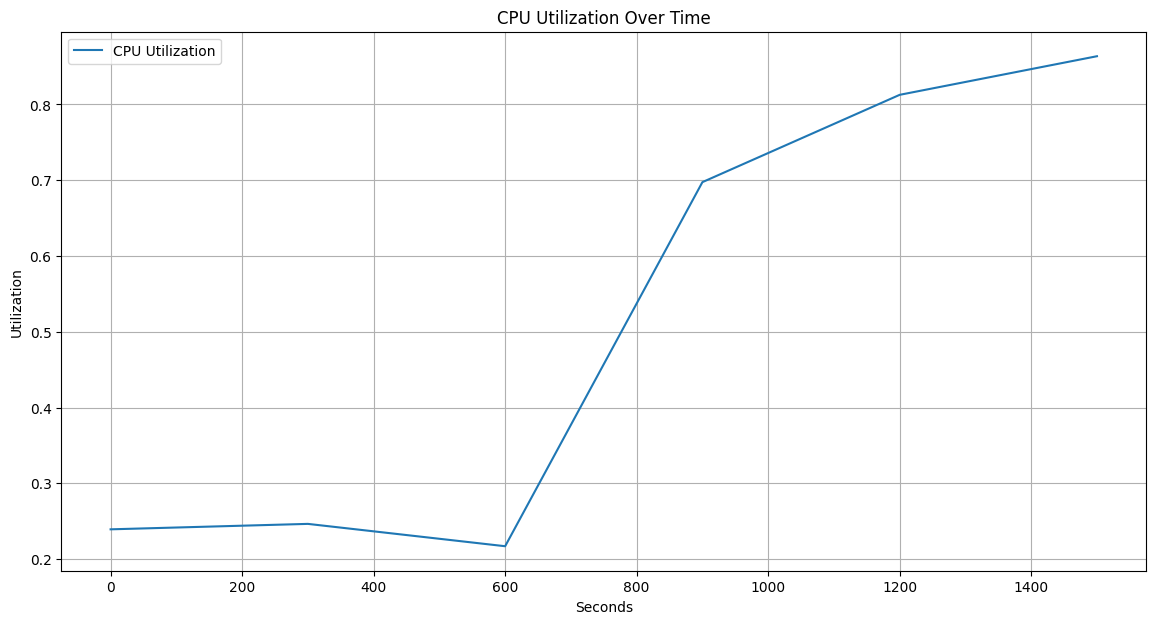

In [9]:
plot_cpu_memory_utilization('data/processed/MS_98_POD_5.csv')